In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Upload file in Colab
from google.colab import files
uploaded = files.upload()

# Read dataset
df = pd.read_csv("startup_funding.csv")

print(df.shape)
df.head()

Saving startup_funding.csv to startup_funding.csv
(3044, 10)


,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [2]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Sr No              3044 non-null   int64 
 1   Date dd/mm/yyyy    3044 non-null   object
 2   Startup Name       3044 non-null   object
 3   Industry Vertical  2873 non-null   object
 4   SubVertical        2108 non-null   object
 5   City  Location     2864 non-null   object
 6   Investors Name     3020 non-null   object
 7   InvestmentnType    3040 non-null   object
 8   Amount in USD      2084 non-null   object
 9   Remarks            419 non-null    object
dtypes: int64(1), object(9)
memory usage: 237.9+ KB
None

Missing Values:
Sr No                   0
Date dd/mm/yyyy         0
Startup Name            0
Industry Vertical     171
SubVertical           936
City  Location        180
Investors Name         24
InvestmentnType         4
Amount in USD         960
Remarks              

In [3]:
df.drop_duplicates(inplace=True)

df['Amount in USD'] = (
    df['Amount in USD']
    .astype(str)
    .str.replace(',', '')
    .str.replace('+', '')
)

df['Amount in USD'] = pd.to_numeric(
    df['Amount in USD'],
    errors='coerce'
)

df['Amount in USD'].fillna(
    df['Amount in USD'].median(),
    inplace=True
)

/tmp/ipykernel_893/3521186674.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Amount in USD'].fillna(


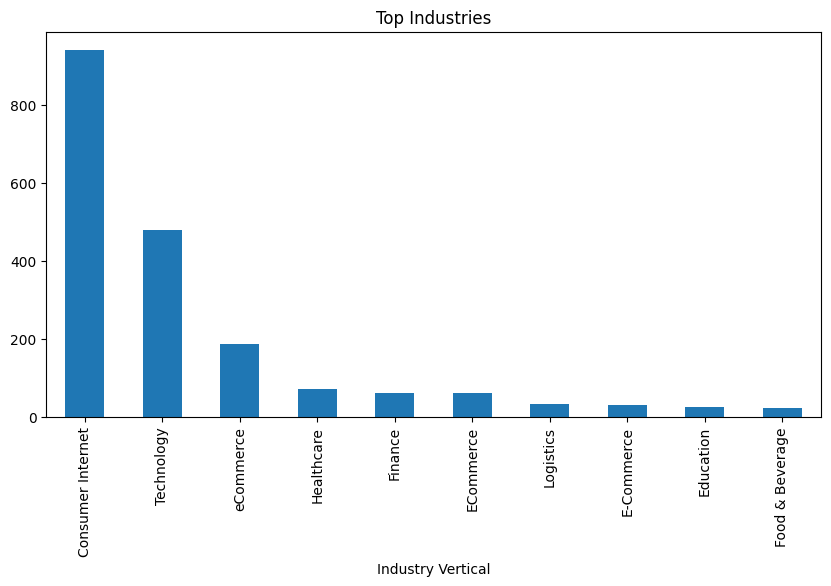

In [4]:
plt.figure(figsize=(10,5))

df['Industry Vertical'].value_counts().head(10).plot(kind='bar')

plt.title("Top Industries")
plt.show()

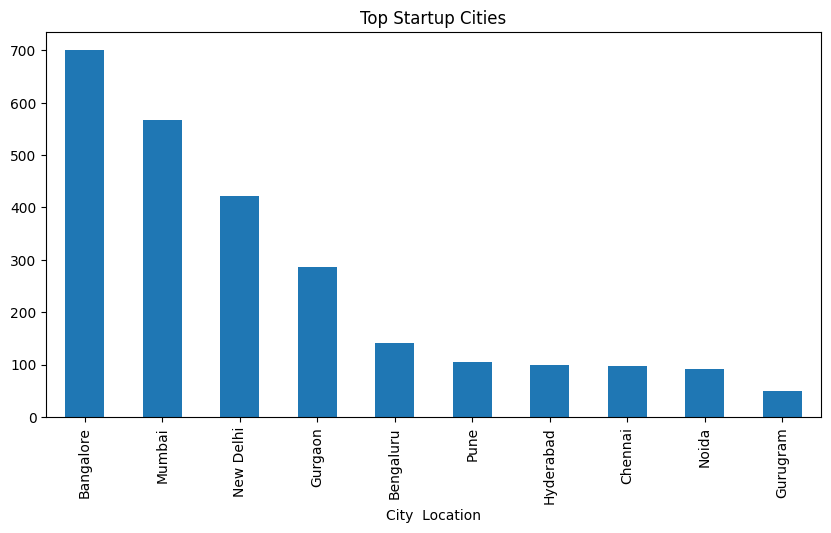

In [6]:
plt.figure(figsize=(10,5))

df['City  Location'].value_counts().head(10).plot(kind='bar')

plt.title("Top Startup Cities")
plt.show()

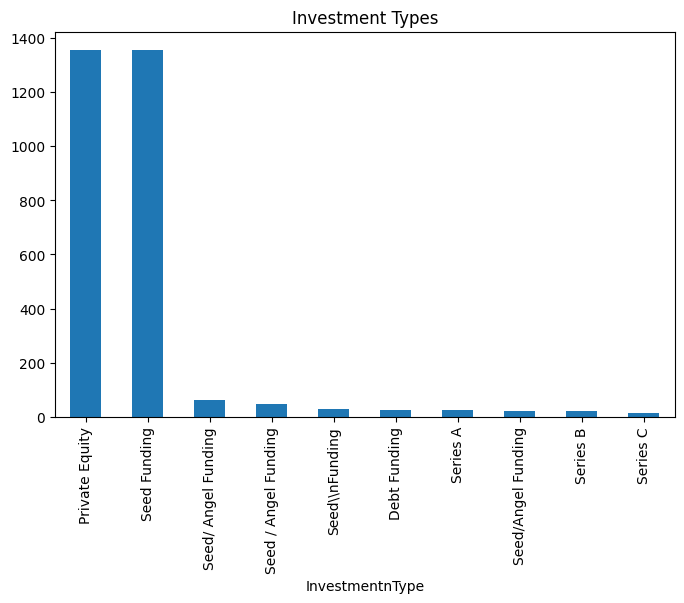

In [7]:
plt.figure(figsize=(8,5))

df['InvestmentnType'].value_counts().head(10).plot(kind='bar')

plt.title("Investment Types")
plt.show()

In [8]:
print("Mean Funding:",
      df['Amount in USD'].mean())

print("Median Funding:",
      df['Amount in USD'].median())

print("Std Funding:",
      df['Amount in USD'].std())

Mean Funding: 13061474.98824573
Median Funding: 1725000.0
Std Funding: 100264267.76975164


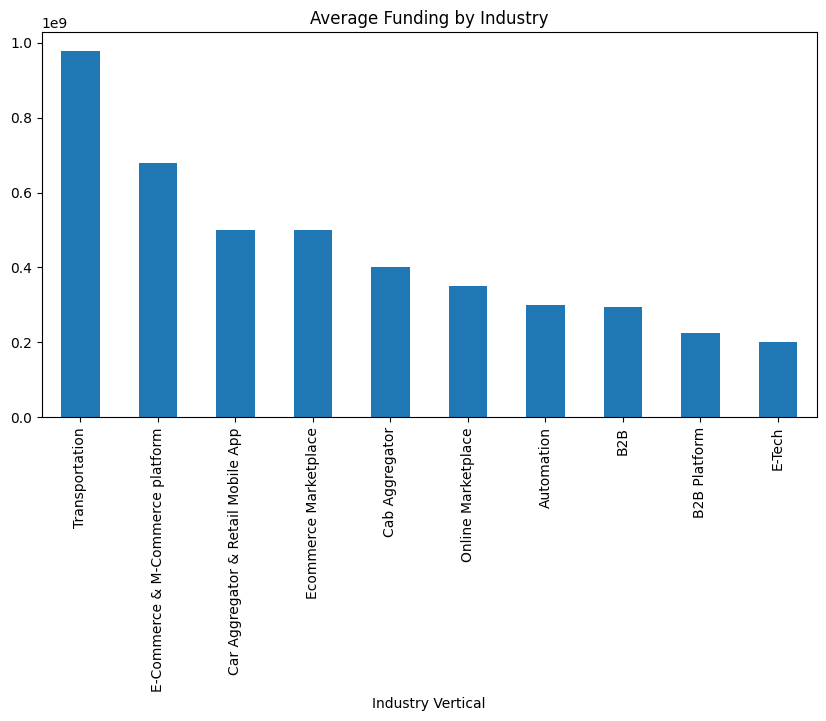

In [9]:
industry_funding = df.groupby(
    'Industry Vertical'
)['Amount in USD'].mean().sort_values(
    ascending=False
).head(10)

industry_funding.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Average Funding by Industry")
plt.show()

In [10]:
np.random.seed(42)

df2 = df.copy()

df2['Founder_Experience'] = np.random.randint(
    0,15,len(df2)
)

df2['Team_Size'] = np.random.randint(
    2,50,len(df2)
)

df2['Startup_Age'] = np.random.randint(
    1,10,len(df2)
)

df2['Growth_Rate'] = np.random.randint(
    5,100,len(df2)
)

df2['Revenue'] = np.random.randint(
    100000,10000000,len(df2)
)

In [11]:
median_funding = df2['Amount in USD'].median()

df2['Funding_Status'] = np.where(
    df2['Amount in USD'] >= median_funding,
    'Funded',
    'Not Funded'
)

df2[['Amount in USD',
     'Funding_Status']].head()

,Amount in USD,Funding_Status
0,200000000.0,Funded
1,8048394.0,Funded
2,18358860.0,Funded
3,3000000.0,Funded
4,1800000.0,Funded


In [12]:
success_rate = (
    df2['Funding_Status']
    .value_counts(normalize=True)
    *100
)

print(success_rate)

Funding_Status
Funded        66.064389
Not Funded    33.935611
Name: proportion, dtype: float64


In [13]:
df2[['Founder_Experience',
     'Team_Size',
     'Startup_Age',
     'Growth_Rate',
     'Revenue']].describe()

,Founder_Experience,Team_Size,Startup_Age,Growth_Rate,Revenue
count,3044.000000,3044.000000,3044.000000,3044.000000,3.044000e+03
mean,6.968134,25.600526,5.005585,53.158344,5.000545e+06
std,4.357274,13.713900,2.564380,27.452547,2.816418e+06
min,0.000000,2.000000,1.000000,5.000000,1.032120e+05
25%,3.000000,14.000000,3.000000,29.000000,2.602502e+06
50%,7.000000,25.000000,5.000000,54.500000,4.964248e+06
75%,11.000000,37.000000,7.000000,77.000000,7.350002e+06
max,14.000000,49.000000,9.000000,99.000000,9.993975e+06


In [14]:
total = len(df2[df2['Founder_Experience']>5])

success = len(
    df2[
        (df2['Founder_Experience']>5)
        &
        (df2['Funding_Status']=="Funded")
    ]
)

print(
    "Probability =",
    success/total
)

Probability = 0.6668499175371083


In [16]:
city_prob = df2.groupby(
    'City  Location'
)['Funding_Status'].apply(
    lambda x:(x=="Funded").mean()
)

print(city_prob.sort_values(
    ascending=False
).head(10))

City  Location
Agra                      1.0
Ahemdabad                 1.0
Andheri                   1.0
Bengaluru and Gurugram    1.0
Bangalore/ Bangkok        1.0
Bangalore / USA           1.0
Bangalore / San Mateo     1.0
Bangalore / SFO           1.0
Chennai/ Singapore        1.0
Faridabad                 1.0
Name: Funding_Status, dtype: float64


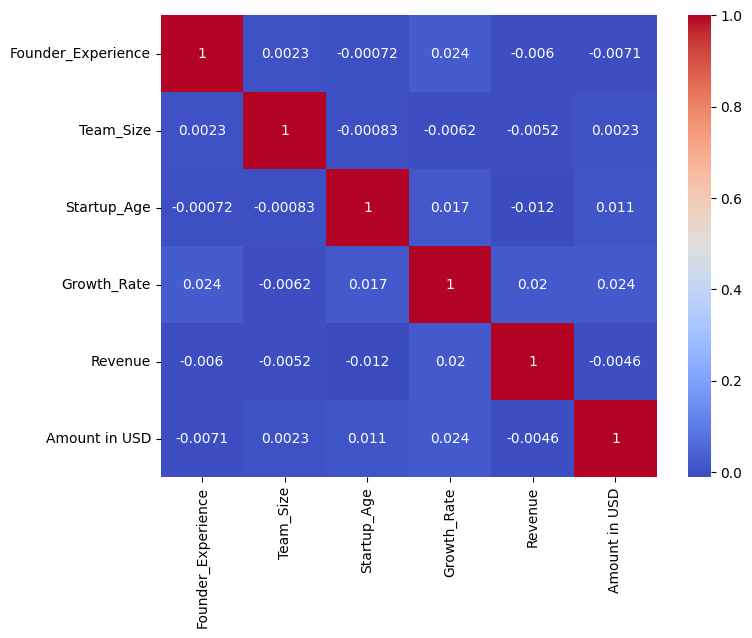

In [17]:
numeric_cols = [
    'Founder_Experience',
    'Team_Size',
    'Startup_Age',
    'Growth_Rate',
    'Revenue',
    'Amount in USD'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df2[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

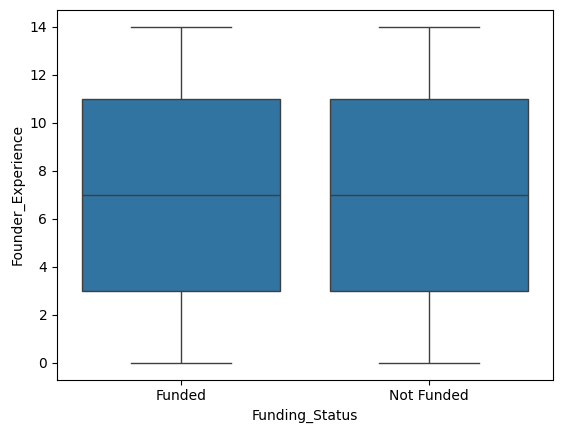

In [18]:
sns.boxplot(
    x='Funding_Status',
    y='Founder_Experience',
    data=df2
)

plt.show()

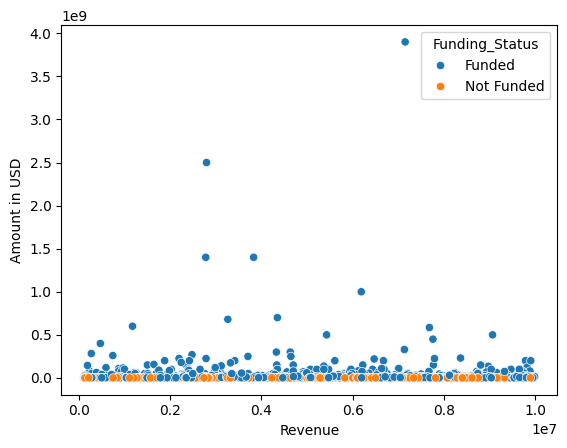

In [19]:
sns.scatterplot(
    x='Revenue',
    y='Amount in USD',
    hue='Funding_Status',
    data=df2
)

plt.show()

In [20]:
from scipy.stats import ttest_ind

funded = df2[
    df2['Funding_Status']=="Funded"
]['Founder_Experience']

not_funded = df2[
    df2['Funding_Status']=="Not Funded"
]['Founder_Experience']

t_stat,p_value = ttest_ind(
    funded,
    not_funded
)

print("T-statistic:",t_stat)
print("P-value:",p_value)

if p_value < 0.05:
    print("Reject H0")
    print("Founder Experience influences Funding")
else:
    print("Fail to Reject H0")

T-statistic: 0.49263380900050935
P-value: 0.622306908519517
Fail to Reject H0


In [21]:
conditions = [
    df2['Growth_Rate'] > 70,
    df2['Founder_Experience'] > 8,
    df2['Revenue'] > 5000000
]

choices = [
    "High Growth",
    "Experienced Founder",
    "Revenue Driven"
]

df2['Segment'] = np.select(
    conditions,
    choices,
    default='High Risk'
)

print(
    pd.crosstab(
        df2['Segment'],
        df2['Funding_Status']
    )
)



Funding_Status       Funded  Not Funded
Segment                                
Experienced Founder     558         259
High Growth             653         329
High Risk               399         234
Revenue Driven          401         211


In [22]:
print("""
1. Experienced founders show better funding outcomes.

2. Certain cities attract higher investments.

3. High-growth startups have better funding probability.

4. Revenue-driven startups attract investors.

5. Investors should prioritize:
   - Founder experience
   - Revenue growth
   - High-growth sectors
""")


1. Experienced founders show better funding outcomes.

2. Certain cities attract higher investments.

3. High-growth startups have better funding probability.

4. Revenue-driven startups attract investors.

5. Investors should prioritize:
   - Founder experience
   - Revenue growth
   - High-growth sectors

